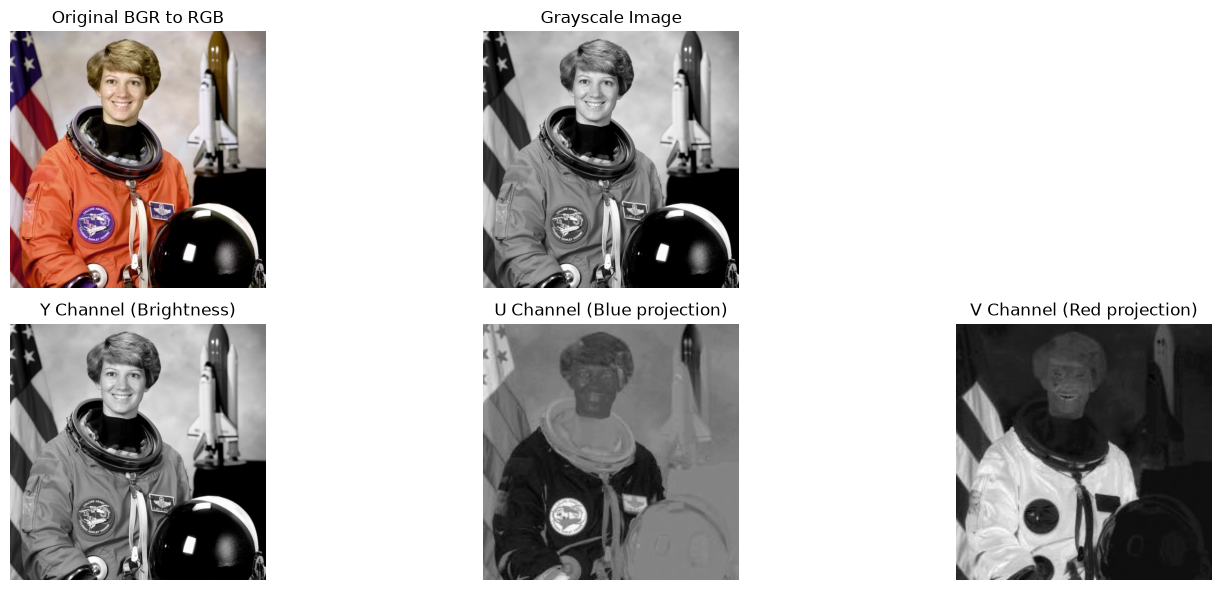

Total OpenCV COLOR_ conversion flags: 374


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data


os.makedirs('images', exist_ok=True)


test_rgb = data.astronaut()
test_bgr = cv2.cvtColor(test_rgb, cv2.COLOR_RGB2BGR)
cv2.imwrite('images/input.jpg', test_bgr)


img = cv2.imread('images/input.jpg')
gray_img = cv2.imread('images/input.jpg', cv2.IMREAD_GRAYSCALE)


cv2.imwrite('images/output.jpg', gray_img)


yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
y_channel = yuv_img[:, :, 0]
u_channel = yuv_img[:, :, 1]
v_channel = yuv_img[:, :, 2]


plt.figure(figsize=(15, 6))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original BGR to RGB')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(y_channel, cmap='gray')
plt.title('Y Channel (Brightness)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(u_channel, cmap='gray')
plt.title('U Channel (Blue projection)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(v_channel, cmap='gray')
plt.title('V Channel (Red projection)')
plt.axis('off')

plt.tight_layout()
plt.show()


color_flags = [x for x in dir(cv2) if x.startswith('COLOR_')]
print(f"Total OpenCV COLOR_ conversion flags: {len(color_flags)}")

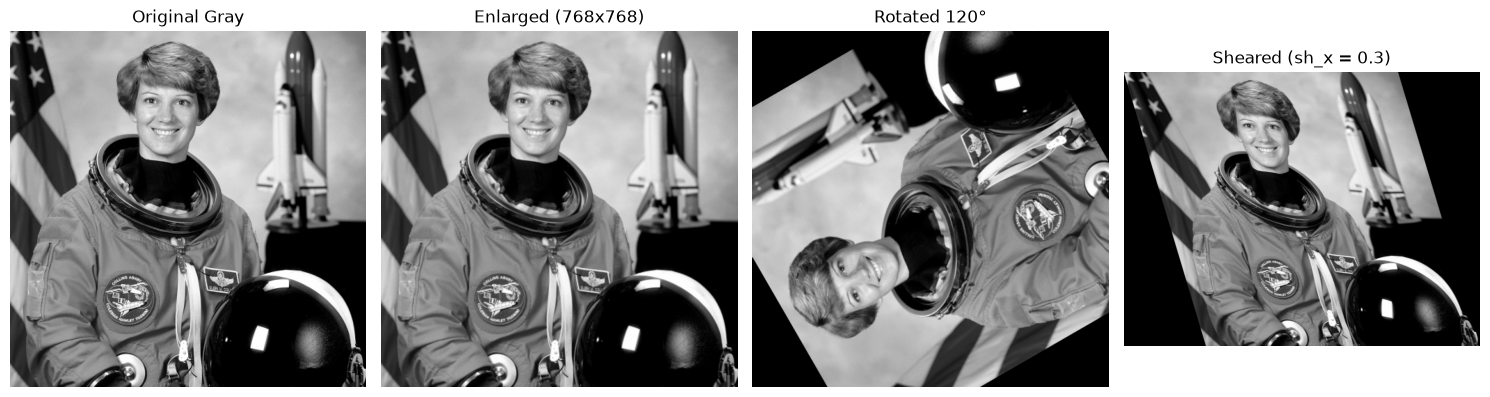

In [2]:
h, w = gray_img.shape[:2]


scale_factor = 1.5
enlarged_img = cv2.resize(gray_img, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)


center = (w // 2, h // 2)
rot_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated_img = cv2.warpAffine(gray_img, rot_matrix, (w, h))


shear_factor = 0.3
shear_matrix = np.float32([
    [1, shear_factor, 0],
    [0, 1, 0]
])

new_w = int(w + h * shear_factor)
sheared_img = cv2.warpAffine(gray_img, shear_matrix, (new_w, h))


plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('Original Gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(enlarged_img, cmap='gray')
plt.title(f'Enlarged ({enlarged_img.shape[1]}x{enlarged_img.shape[0]})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(rotated_img, cmap='gray')
plt.title('Rotated 120°')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(sheared_img, cmap='gray')
plt.title('Sheared (sh_x = 0.3)')
plt.axis('off')

plt.tight_layout()
plt.show()

C:\Users\azozk\AppData\Local\Temp\ipykernel_21400\39131763.py:5: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(gray_img))
C:\Users\azozk\AppData\Local\Temp\ipykernel_21400\39131763.py:5: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(gray_img))


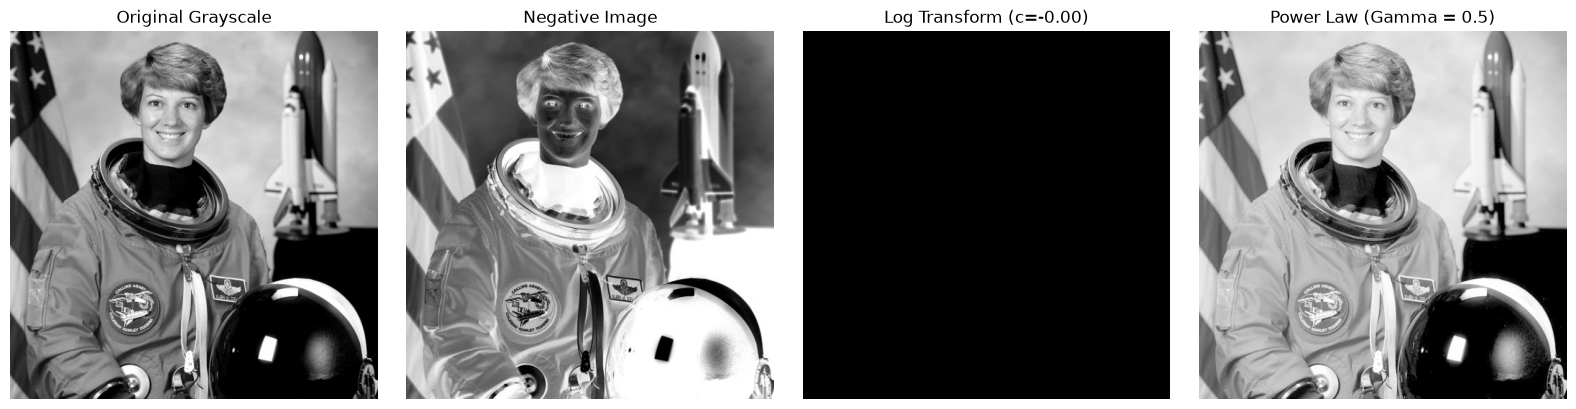

In [3]:

negative_img = 255 - gray_img



c = 255 / np.log(1 + np.max(gray_img))
log_transformed = c * (np.log(1 + gray_img.astype(np.float32)))
log_img = np.array(log_transformed, dtype=np.uint8)



gamma = 0.5
gamma_transformed = 255 * np.power(gray_img / 255.0, gamma)
gamma_img = np.array(gamma_transformed, dtype=np.uint8)


plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(negative_img, cmap='gray')
plt.title('Negative Image')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(log_img, cmap='gray')
plt.title(f'Log Transform (c={c:.2f})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(gamma_img, cmap='gray')
plt.title(f'Power Law (Gamma = {gamma})')
plt.axis('off')

plt.tight_layout()
plt.show()